## <em> Linear Algebra - Gaussian Elimination, SVD, Polynomial Regression</em>

***

### Imports

In [1]:
import numpy as np
from scipy.integrate import quad
import sklearn as sk
from sklearn import datasets, linear_model
from sklearn.preprocessing import PolynomialFeatures
#For plotting
import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib import cm
import matplotlib
from matplotlib import rcParams
from matplotlib.pyplot import figure
from matplotlib import rc
import pylab
import os

pgf_with_latex = {
        'text.usetex': False,
        'pgf.rcfonts': False,
        "pgf.preamble": [
                r"\usepackage{siunitx}"
                ]
}


%matplotlib inline


universal_linewidth=2
universal_fontsize=25

***

#### Solving Least Squares Using Normal Equations and SVD

(Reference - NR 15.4) We fit a set of 50 data points $(x_i, y_i)$ to a polynomial $y(x) = a_0 + a_1x + a_2x^2 + a_3x^3$. (Note that this problem is linear in $a_i$ but nonlinear in $x_i$). The uncertainty $\sigma_i$ associated with each measurement $y_i$ is known, and we assume that the $x_i$'s are known exactly. To measure how well the model agrees with the data, we use the chi-square merit function: <br>
$$ \chi^2 = \sum_{i=0}^{N-1} \big( \frac{y_i-\sum_{k=0}^{M-1}a_k x^k}{\sigma_i} \big)^2. $$
<br>
where N = 50 and M = 4. Here, $1, x, ... , x^3$ are the basis functions.
<br><br>
<span style="color:blue"> <i> Plot data. (Hint - https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.errorbar.html) </i></span><br>


In [33]:
# Load a given 2D data
data = np.loadtxt("./data_1.dat")
x = data[:,0]
y = data[:,1]
sig_y = data[:,2]

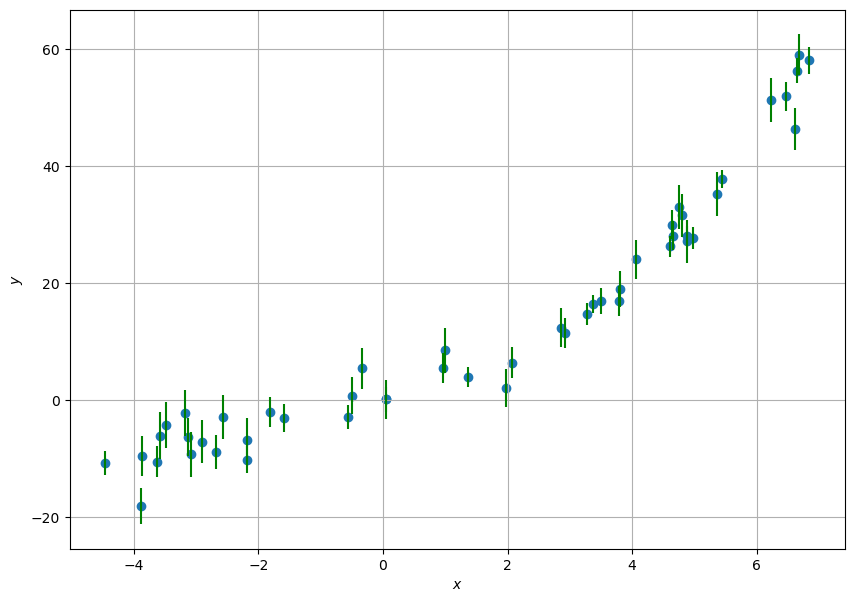

In [10]:
# Make plot
plt.figure(figsize = (10, 7))
# Scatter plot
plt.scatter(x,y)
plt.errorbar(x, y, yerr=sig_y, fmt='none', ecolor='green')


plt.xlabel('$x$') 
plt.ylabel('$y$')
plt.grid()
plt.show()

We will pick as best parameters those that minimize $\chi^2$.<br><br>
First, let $\bf A$ be a matrix whose $N \times M$ components are constructed from the $M$ basis functions evaluated at the $N$ abscissas $x_i$, and from the $N$ measurement errors $\sigma_i$, by the prescription
$$ A_{ij} = \frac{X_j(x_i)}{\sigma_i} $$
<br>where $X_0(x) = 1,\ X_1(x) = x,\ X_2(x) = x^2,\ X_3(x) = x^3$. We call this matrix $\bf A$ the design matrix.
<br><br>
Also, define a vector $\bf b$ of length $N$ by
$$ b_i = \frac{y_i}{\sigma_i} $$
<br>and denote the $M$ vector whose components are the parameters to be fitted ($a_0, a_1, a_2, a_3$) by $\bf a$.
<br><br>
<span style="color:blue"><i> Define the design matrix A. (Hint: Its dimension should be NxM = 50x4.) Also, define the vector b. Print the first row of A. </i></span><br>


In [21]:
# Define A
N,M = (50,4)

A = np.zeros((50,4))
for i in range(N):
    for j in range(M):
        A[i][j]=(x[i]**j)/sig_y[i]

# shorthand method for A: 
# A2 = np.vstack([1./sig_y, x/sig_y, (x**2)/sig_y, (x**3)/sig_y]).T        
        
B = np.empty((N,M), dtype='object')
for i in range(N):
    for j in range(M):
        B[i][j]=f'X[{i}]**{j}/sig_y[{i}]'

# Define b
b = y/sig_y

# Print the first row of A
print(B[0][0], B[0][1],  B[0][2],  B[0][3])

X[0]**0/sig_y[0] X[0]**1/sig_y[0] X[0]**2/sig_y[0] X[0]**3/sig_y[0]


Minimize $\chi^2$ by differentiating it with respect to all $M$ parameters $a_k$ vaishes. This condition yields the matrix equation 
<br>  
$$ \sum_{j=0}^{M-1} \alpha_{kj}a_j = \beta_k$$
  
<br> where $\bf \boldsymbol \alpha = A^T \cdot A$ and $\bf \boldsymbol \beta = A^T \cdot b$ ($\boldsymbol \alpha$ is an $M \times M$ matrix, and $\boldsymbol \beta$ is a vector of length $M$). This is the normal equation of the least squares problem. In matrix form, the normal equations can be written as:
$$ \bf \boldsymbol \alpha \cdot a = \boldsymbol \beta. $$
<br><br>
This can be solved for the vector of parameters $\bf a$ by linear algebra numerical methods.
<br><br>
<span style="color:blue"> <i> Define the matrix alpha and vector beta. Print both alpha and beta. </i></span><br>

In [25]:
# Transpose of the matrix A
A_transpose = A.transpose()

# alpha matrix
alpha = np.dot(A_transpose,A)
# beta vector
beta = np.dot(A_transpose,b)

# Print alpha and beta
print('alpha:\n', alpha) 
print('\nbeta:\n', beta)

alpha:
 [[7.57344292e+00 1.59581405e+01 1.20838371e+02 4.80208969e+02]
 [1.59581405e+01 1.20838371e+02 4.80208969e+02 3.20704253e+03]
 [1.20838371e+02 4.80208969e+02 3.20704253e+03 1.62887892e+04]
 [4.80208969e+02 3.20704253e+03 1.62887892e+04 1.05149671e+05]]

beta:
 [  118.53904396   727.88040211  3581.30337095 22023.93157276]


<span style="color:blue"> <i> We have $ \bf \boldsymbol \alpha \cdot a = \boldsymbol \beta. $ Solve for $\bf a$ using (1) "GaussianElimination_pivot" defined below (2) LU decomposition and forward subsitution and backsubstitution. Plot the best-fit line on top of the data. </i></span><br>

Hint: You can use scipy.linalg.lu to do the LU decomposition. After you do "L, U = lu(A, permute_l=True)," print L and U matrices. Note that L is not a lower triangle matrix. Swap rows of L (and B) and make it a lower triangular matrix. And then, solve for y in Ly = B.
e.g.

If your matrix \( L \) is:

$$L =\begin{bmatrix}
0.01577114 & 0.10593754 & 0.41569921 & 1 \\
0.03323166 & -0.04364428 & 1 & 0 \\
0.25163705 & 1 & 0 & 0 \\
1 & 0 & 0 & 0
\end{bmatrix}$$


you can rewrite it as:

$$ L =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0.25163705 & 1 & 0 & 0 \\
0.03323166 & -0.04364428 & 1 & 0 \\
0.01577114 & 0.10593754 & 0.41569921 & 1
\end{bmatrix}
$$

Then, you should also reorder the vector \( B \) from:

$$B =
\begin{bmatrix}
118.53904396 \\
727.88040211 \\
3581.30337095 \\
22023.93157276
\end{bmatrix}
$$

to:

$$B =
\begin{bmatrix}
22023.93157276 \\
3581.30337095 \\
727.88040211 \\
118.53904396
\end{bmatrix}
$$

In [26]:
def GaussianElimination_pivot(A, b):

    N = len(b)

    for m in range(N):

        # Check if A[m,m] is the largest value from elements bellow and perform swapping
        for i in range(m+1,N):
            if A[m,m] < A[i,m]:
                A[[m,i],:] = A[[i,m],:]
                b[[m,i]] = b[[i,m]]

        # Divide by the diagonal element
        div = A[m,m]
        A[m,:] /= div
        b[m] /= div

        # Now subtract from the lower rows
        for i in range(m+1,N):
            mult = A[i,m]
            A[i,:] -= mult*A[m,:]
            b[i] -= mult*b[m]

    # Backsubstitution
    x = np.empty(N,float)
    for m in range(N-1,-1,-1):
        x[m] = b[m]
        for i in range(m+1,N):
            x[m] -= A[m,i]*x[i]

    return x

In [27]:
# Using the Gaussian elimination with partial pivoting
a = GaussianElimination_pivot(alpha, beta)

print('Using Gaussian Elimination:')
print('a0 =', a[0], ', a1 =', a[1], ', a2 =', a[2], ', a3 =', a[3])

Using Gaussian Elimination:
a0 = -0.03081629537270203 , a1 = 2.6676460822498753 , a2 = 0.3148392700785264 , a3 = 0.07945935335134538


In [28]:
# "lu" does LU decomposition with pivot. Reference - https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.linalg.lu_factor.html
from scipy.linalg import lu

def forward_sub(L, B):
    """x = forward_sub(L, B) is the solution to Ly = B
       L must be a lower-triangular matrix
       B must be a vector of the same leading dimension as L
    """
    n = L.shape[0]
    y = np.zeros(n)
    for i in range(n):
        tmp = B[i]
        for j in range(i):
            tmp -= L[i,j] * y[j]
        y[i] = tmp / L[i,i]
    return y

def back_sub(U, b):
    """x = back_sub(U, b) is the solution to U x = b
       U must be an upper-triangular matrix
       b must be a vector of the same leading dimension as U
    """
    n = U.shape[0]
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        tmp = b[i]
        for j in range(i+1, n):
            tmp -= U[i,j] * x[j]
        x[i] = tmp / U[i,i]
    return x


def solve_lu_pivot(A, B):
    # LU decomposition with pivot
    L, U = lu(A, permute_l=True)

    N = len(B)

    # forward substitution: We have Ly = B. Solve for y
    y = forward_sub(L, B)

    # backward substitution: We have y = Ux. Solve for x.
    x = back_sub(U, y)

    return (x,L,U)

a,L,U = solve_lu_pivot(alpha, beta)

print('Using LU Decomposition:\n')
print(f'Matrix L: \n{L}\n')
print(f'Matrix U: \n{U}\n')
print('a0 =', a[0], ', a1 =', a[1], ', a2 =', a[2], ', a3 =', a[3])

Using LU Decomposition:

Matrix L: 
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [-0. -0.  1.  0.]
 [-0. -0. -0.  1.]]

Matrix U: 
[[  1.           6.67843114  33.92021025 218.9664876 ]
 [  0.           1.          -4.28341781 -20.13986252]
 [  0.           0.           1.           6.59533249]
 [  0.           0.           0.           1.        ]]

a0 = -0.03081629537270203 , a1 = 2.6676460822498753 , a2 = 0.3148392700785264 , a3 = 0.07945935335134538


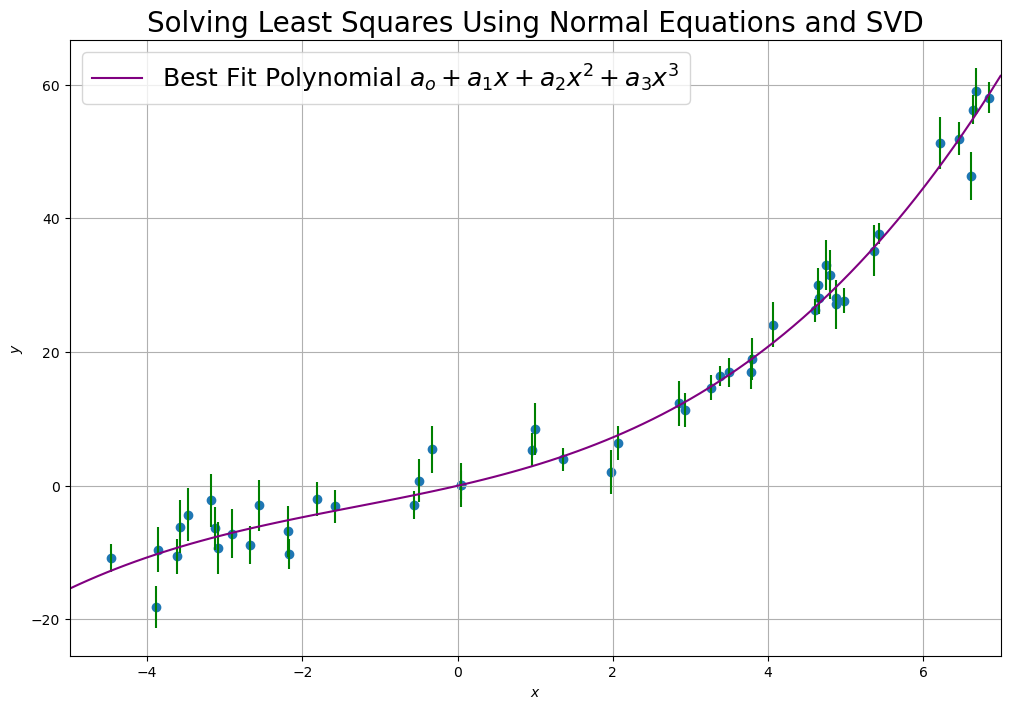

In [39]:
# Make plot
# Best Fit line

def poly(a,x):
    return a[0] + a[1]*x + a[2]*(x**2) + a[3]*(x**3)

plt.figure(figsize = (10, 7))
plt.scatter(x,y)
plt.errorbar(x, y, yerr=sig_y, fmt='none', ecolor='green')

xx = np.linspace(-5, 7, 100)
plt.plot(xx,poly(a,xx), color='purple',label= r'Best Fit Polynomial $a_o + a_1x + a_2x^2 + a_3x^3$')

plt.title('Solving Least Squares Using Normal Equations and SVD', fontsize=universal_fontsize-5)
plt.tight_layout()
plt.legend(fontsize=universal_fontsize-7)
plt.xlabel('$x$') 
plt.ylabel('$y$')
plt.xlim(-5, 7)
plt.grid()

The inverse matrix $\bf C = \boldsymbol \alpha^{-1}$ is called the covariance matrix, which is closely related to the probable uncertainties of the estimated parameters $\bf a$. To estimate these uncertainties, we compute the variance associated with the estimate $a_j$. Following NR p.790, we obtain: <br><br>
$$ \sigma^2(a_j) = \sum_{k=0}^{M-1} \sum_{l=0}^{M-1} C_{jk} C_{jl} \alpha_{kl} = C_{jj} $$
<br>
<span style="color:blue"> <i> Compute the error (standard deviation - square root of the variance) on the fitted parameters using the covariance matrix. </i></span><br>

In [41]:
from scipy.linalg import inv
# Covariance matrix

alpha = np.dot(A_transpose, A) 
C = inv(alpha)
C0 = C[0, :] 
C1 = C[1, :] 
C2 = C[2, :] 
C3 = C[3, :]

sigma_a0 = np.sqrt(np.dot(C0, np.dot(alpha, C0.T))) 
sigma_a1 = np.sqrt(np.dot(C1, np.dot(alpha, C1.T))) 
sigma_a2 = np.sqrt(np.dot(C2, np.dot(alpha, C2.T))) 
sigma_a3 = np.sqrt(np.dot(C3, np.dot(alpha, C3.T)))

print('Errors: \non a0 =', sigma_a0, ' \non a1 =', sigma_a1,
      ' \non a2 =', sigma_a2, ' \non a3 =', sigma_a3)

Errors: 
on a0 = 0.7139418927087795  
on a1 = 0.22390274023290246  
on a2 = 0.06344814294696757  
on a3 = 0.011998696856719228


Now, instead of using the normal equations, we use singular value decomposition (SVD) to find the solution of least squares. Please read Ch. 15 of NR for more details. Remember that we have the $N \times M$ design matrix $\bf A$ and the vector $\bf b$ of length $N$. We wish to mind $\bf a$ which minimizes $\chi^2 = |\bf A \cdot a - b|^2$.
<br><br>
Using SVD, we can decompose $\bf A$ as the product of an $N \times M$ column-orthogonal matrix $\bf U$, an $M \times M$ diagonal matrix $\bf S$ (with positive or zero elements - the "singular" values), and the transpose of an $M \times M$ orthogonal matrix $\bf V$. ($\bf A = USV^{T}$). <br>
Let $\bf U_{(i)}$ and $\bf V_{(i)}$ denote the columns of $\bf U$ and $\bf V$ respectively (Note: We get $M$ number of vectors of length $M$.) $\bf S_{(i,i)}$ are the $i$th diagonal elements (singular values) of $\bf S$. Then, the solution of the above least squares problem can be written as:
<br>
$$ \bf a = \sum_{i=1}^M \big( \frac{U_{(i)} \cdot b}{S_{(i,i)}} \big) V_{(i)}. $$
<br><br>
The variance in the estimate of a parameter $a_j$ is given by:
$$ \sigma^2(a_j) = \sum_{i=1}^M \big( \frac{V_{ji}}{S_{ii}} \big)^2 $$
<br>
and the covariance:
$$ \mathrm{Cov}(a_j, a_k) = \sum_{i=1}^M \big( \frac{V_{ji}V_{ki}}{S_{ii}^2} \big). $$
<br><br>
<span style="color:blue"> <i> Decompose the design matrix A using SVD. Estimate the parameter $a_i$'s and its variance. </i></span><br>

In [44]:
# Reference - https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.linalg.svd.html
from scipy.linalg import svd

# Decompose A
# Note: S, in this case, is a vector of length M, which contains the singular values.
U, S, VT = svd(A, full_matrices=False)
V = VT.T

# Solve for a
coeff = []
for i in range(M):
    coeff.append(np.dot(U.T[i], b)/S.T[i])

a_from_SVD = coeff[0]*VT[0]+coeff[1]*VT[1]+coeff[2]*VT[2]+coeff[3]*VT[3]


print('Using SVD:')
print('a0 =', a_from_SVD[0], '\na1 =', a_from_SVD[1], '\na2 =', a_from_SVD[2], '\na3 =', a_from_SVD[3])

Using SVD:
a0 = -0.03081629537271724 
a1 = 2.6676460822498784 
a2 = 0.3148392700785293 
a3 = 0.07945935335134485


In [45]:
sigma_a_SVD = [np.sqrt(sum([(V[j][i]/S.T[i])**2 for i in range(M)])) for j in range(M)]


print('Error from SVD:\non a0 =', sigma_a_SVD[0], '\non a1 =', sigma_a_SVD[1],
      '\non a2 =', sigma_a_SVD[2], '\non a3 =', sigma_a_SVD[3])

Error from SVD:
on a0 = 0.7139418927087805 
on a1 = 0.22390274023290238 
on a2 = 0.0634481429469677 
on a3 = 0.01199869685671928


Suppose that you are only interested in the parameters $a_0$ and $a_1$. We can plot the 2-dimensional confidence region ellipse for these parameters by building the covariance matrix:
$$ \mathrm{C'} =  \binom{\sigma({a_0})^2\ \ \ \ \ \ \mathrm{Cov}({a_0, a_1})}{\mathrm{Cov}({a_0, a_1}) \ \ \ \ \ \ \sigma({a_1})^2} $$
<br><br>
The lengths of the ellipse axes are the square root of the eigenvalues of the covariance matrix, and we can calculate the counter-clockwise rotation of the ellipse with the rotation angle:
$$ \theta = \frac{1}{2} \mathrm{arctan}\Big( \frac{2\cdot \mathrm{Cov}({a_0, a_1})}{\sigma({a_0})^2-\sigma({a_1})^2} \Big) = \mathrm{arctan}(\frac{\vec{v_1}(y)}{\vec{v_1}(x)}) $$
<br>
where $\vec{v_1}$ is the eigenvector with the largest eigenvalue. So we calculate the angle of the largest eigenvector towards the x-axis to obtain the orientation of the ellipse. <br><br>
<br>
Then, we multiply the axis lengths by some factor depending on the confidence level we are interested in. For 68%, this scale factor is $\sqrt{\Delta \chi^2} \approx 1.52$. For 95%, it is $\approx 2.48$.
<br><br>
<span style="color:blue"> <i> Compute the covariance between $a_0$ and $a_1$. Plot the 68% and 95% confidence region of the parameter $a_0$ and $a_1$.</i></span><br>

In [46]:
from matplotlib.patches import Ellipse
import matplotlib as mpl
from numpy.linalg import eigvals

In [52]:
# Build the covariance matrix
def Cov(j,k):
    return sum([(V[j][i]*V[k][i])/(S.T[i]**2) for i in range(M)])

CovM = np.array([[sigma_a_SVD[0]**2,Cov(0,1)],
                 [Cov(0,1),sigma_a_SVD[1]**2]])
print(CovM)

[[ 0.50971303 -0.05496243]
 [-0.05496243  0.05013244]]


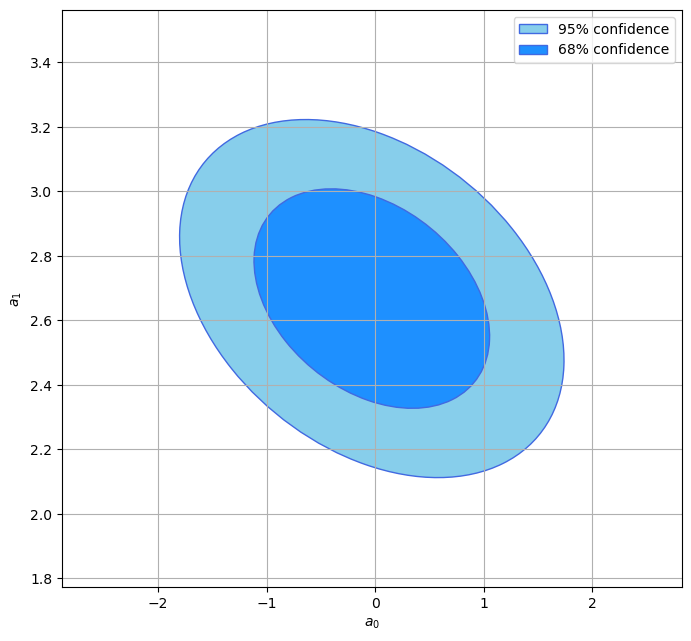

In [53]:
# Plot the confidence region (https://stackoverflow.com/questions/32371996/python-matplotlib-how-to-plot-ellipse)

eigvec, eigval, u = np.linalg.svd(CovM)

# Semimajor axis (diameter)
semimaj = np.sqrt(eigval[0])*2.
# Semiminor axis (diameter)
semimin = np.sqrt(eigval[1])*2.

theta = np.arctan(eigvec[0][1]/eigvec[0][0])

# Plot 1-sig confidence region
ell = mpl.patches.Ellipse(xy=[a[0], a[1]], width=1.52*semimaj, height=1.52*semimin, 
                          angle = theta*180/np.pi, facecolor = 'dodgerblue', 
                          edgecolor = 'royalblue', label = '68% confidence')
# Plot 2-sig confidence region
ell2 = mpl.patches.Ellipse(xy=[a[0], a[1]], width=2.48*semimaj, height=2.48*semimin, 
                           angle = theta*180/np.pi, facecolor = 'skyblue', 
                           edgecolor = 'royalblue', label = '95% confidence')

fig, ax = plt.subplots(figsize=(8,7.5))

ax.add_patch(ell2)
ax.add_patch(ell)

# Set bounds for x,y axes
bounds = np.sqrt(CovM.diagonal())
plt.xlim(a[0]-4*bounds[0], a[0]+4*bounds[0])
plt.ylim(a[1]-4*bounds[1], a[1]+4*bounds[1])

plt.grid(True)
plt.xlabel('$a_0$')
plt.ylabel('$a_1$')
plt.legend()
plt.show()

In data analysis, we fit the existing data to obtain model parameters, while in machine learning we use the model derived from the existing data to make prediction for new data.

Next, let us take the given data and do the polynomial regression.

First, split the sample into training data and the testing data. Keep 80% data as training data and uses the remaining 20% data for testing.

<span style="color:blue"> <i> Often, the data can be ordered in a specific manner, hence shuffle the data prior to splitting it into training and testing samples. (Use https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.shuffle.html) </i></span><br>

In [54]:
data = np.loadtxt("./data_1.dat")
arr = np.arange(50) 
np.random.shuffle(arr)

# Shuffle Data
train_x = x[arr[0:40]] 
train_y = y[arr[0:40]] 
train_sigy = sig_y[arr[0:40]] 
test_x = x[arr[40:]]
test_y = y[arr[40:]] 
test_sigy = sig_y[arr[40:]]

In the case of polynomial regression, we need to generate polynomial features (http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) for preprocessing. Note that we call each term in the polynomial as a "feature" in our model, and here we generate features' high-order (and interaction) terms. For example, suppose we set the degree of the polynomial to be 3. Then, the features of $X$ is transformed from $(X)$ to $(1, X, X^2, X^3)$. We can do this transform using PolynomialFeatures.fit_transform(train_x). But fit_transform() takes the numpy array of shape [n_samples, n_features]. So you need to re-define our training set as train_set_prep = train_x[:,np.newaxis] so that it has the shape [40,1].

<span style="color:blue"> <i> Define three different polynomial models with degree of 1, 3, 10. (e.g. model = PolynomialFeatures(degree=...) ) Then, fit to data and transform it using "fit_transform"  </i></span><br>

In [69]:
# e.g.
model1 = PolynomialFeatures(degree = 1)
X_model1 = model1.fit_transform(train_x[:,np.newaxis])

model3 = PolynomialFeatures(degree = 3)
X_model3 = model3.fit_transform(train_x[:,np.newaxis])

model10 = PolynomialFeatures(degree = 10)
X_model10 = model10.fit_transform(train_x[:,np.newaxis])


Then, do the least squares linear regression. (http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit)

1. define the object for linear regression: LR = linear_model.LinearRegression()
2. Fit the linear model to the training data: LR.fit(transformed x data, y data)
3. Define new x samples for plotting: X_sample = np.linspace(-5, 7, 100)
4. Transform x sample: X_sample_transform = model.fit_transform(X_sample[:,np.newaxis])
4. Predict using the linear model: Y_sample = LR.predict(X_sample_transform)
5. Plot the fit: plt.plot(X_sample, Y_sample)


<span style="color:blue"> <i> Do the linear regression for three different polynomial models defined previously. Plot the fit on top of the training data (Label each curve). </i></span><br>

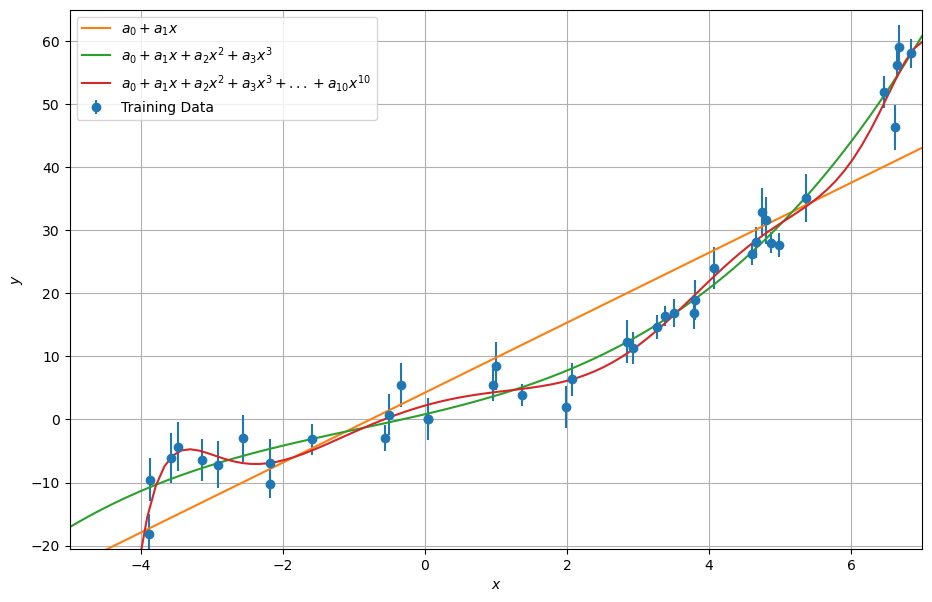

In [96]:
# Make plot
plt.figure(figsize = (11, 7))
plt.errorbar(train_x, train_y, yerr = train_sigy, fmt='o', label = 'Training Data')
plt.plot(X_sample, Y_sample, label = r'$a_0 + a_1x$')
plt.plot(X_sample, Y_sample3, label = r'$a_0 + a_1x + a_2x^2 + a_3x^3$')
plt.plot(X_sample, Y_sample10, label = r'$a_0 + a_1x + a_2x^2 + a_3x^3 + ... + a_{10}x^{10}$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.xlim(-5, 7)
plt.ylim(-20.5, 65)
plt.legend()
plt.grid()
plt.show()


<span style="color:blue"> <i> Plot the fit on top of the test data. </i></span><br>

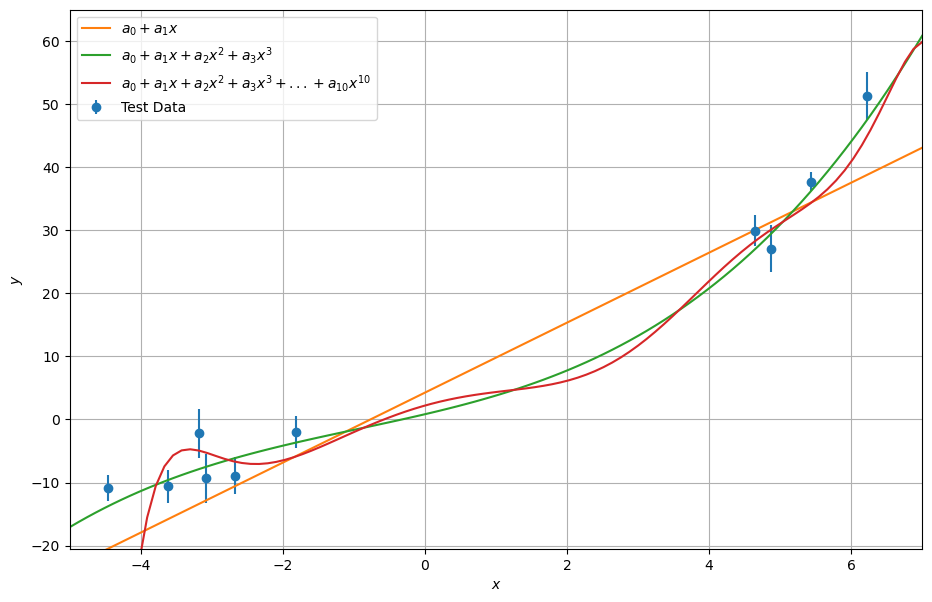

In [97]:
# Make plot
plt.figure(figsize = (11, 7))
plt.errorbar(test_x, test_y, yerr = test_sigy, fmt='o', label = 'Test Data')
plt.plot(X_sample, Y_sample, label = r'$a_0 + a_1x$')
plt.plot(X_sample, Y_sample3, label = r'$a_0 + a_1x + a_2x^2 + a_3x^3$')
plt.plot(X_sample, Y_sample10, label = r'$a_0 + a_1x + a_2x^2 + a_3x^3 + ... + a_{10}x^{10}$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.xlim(-5, 7)
plt.ylim(-20.5, 65)
plt.legend()
plt.grid()
plt.show()

You can obtain the estimated linear coefficients using linear_model.LinearRegression.coef_ (http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression)


<span style="color:blue"> <i> Print the linear coefficients of three polynomial models you used. For the polynomial of degree 10, do you see that high-order coefficients are very small? </i></span><br>

In [98]:
print('polynomial of degree 1: ', LR1.coef_) 
print('polynomial of degree 3: ', LR3.coef_) 
print('polynomial of degree 10: ', LR10.coef_)

polynomial of degree 1:  [0.         5.55014029]
polynomial of degree 3:  [0.         2.63459616 0.24296395 0.08654289]
polynomial of degree 10:  [ 0.00000000e+00  3.18018192e+00 -1.15348352e+00 -1.00357893e-02
  1.16544480e-01  1.11329989e-02  7.76040708e-03 -3.32953010e-03
 -4.59343515e-04  2.00306685e-04 -1.40813365e-05]


***